In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
!pip install torch scikit-learn matplotlib seaborn

# WINE CLASSIFICATION

## DATA EXPLORATION

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset


from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load data and target
X, y = load_wine(return_X_y = True)
print(X.shape)
print(y.shape)

(178, 13)
(178,)


In [4]:
# To see the data
data = load_wine(as_frame = True)
df = data.frame # df w/ features and target
print(df.head())

   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  target  
0          

In [5]:
# To list number of unique target variables: to find out what type of classification this is
print(df['target'].value_counts())

target
1    71
0    59
2    48
Name: count, dtype: int64


array([[<Axes: title={'center': 'alcohol'}>,
        <Axes: title={'center': 'malic_acid'}>,
        <Axes: title={'center': 'ash'}>,
        <Axes: title={'center': 'alcalinity_of_ash'}>],
       [<Axes: title={'center': 'magnesium'}>,
        <Axes: title={'center': 'total_phenols'}>,
        <Axes: title={'center': 'flavanoids'}>,
        <Axes: title={'center': 'nonflavanoid_phenols'}>],
       [<Axes: title={'center': 'proanthocyanins'}>,
        <Axes: title={'center': 'color_intensity'}>,
        <Axes: title={'center': 'hue'}>,
        <Axes: title={'center': 'od280/od315_of_diluted_wines'}>],
       [<Axes: title={'center': 'proline'}>,
        <Axes: title={'center': 'target'}>, <Axes: >, <Axes: >]],
      dtype=object)

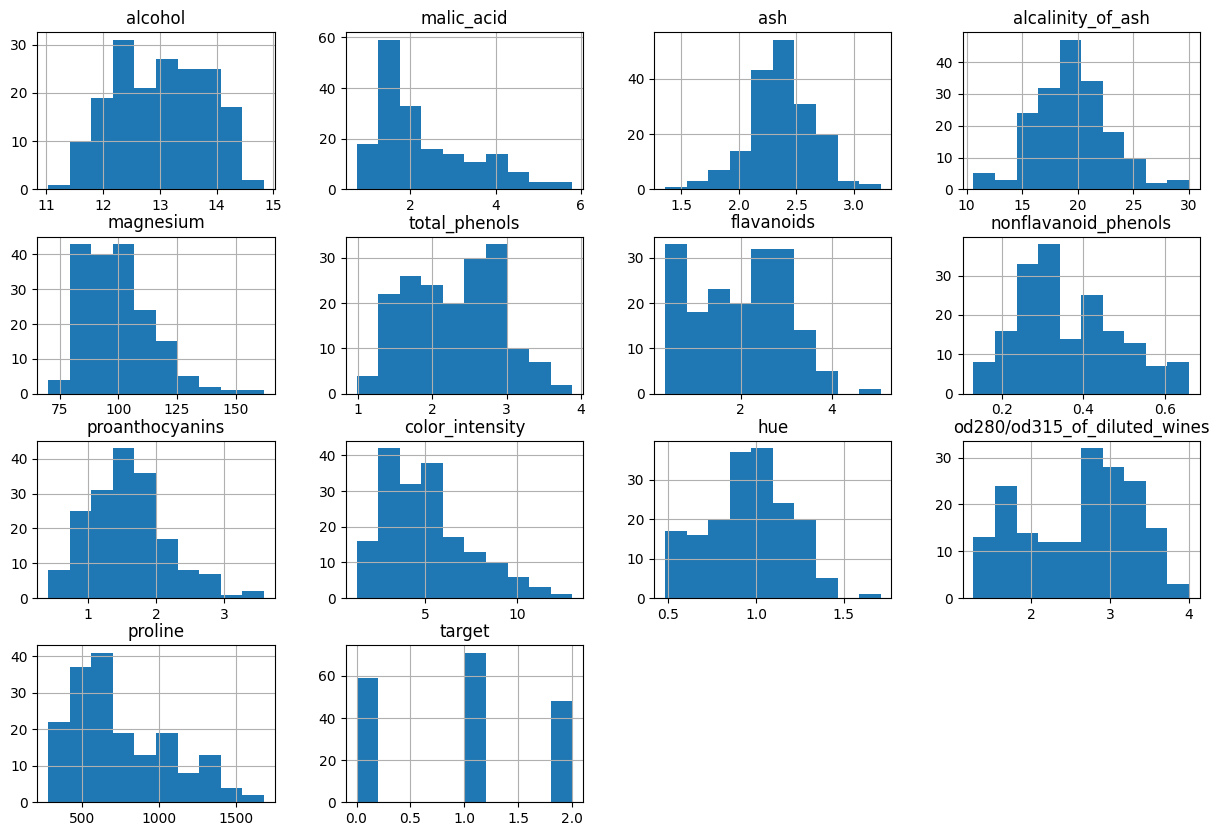

In [6]:
# Since features are all numerical, we can view the distribution of these features
df.hist(figsize=(15, 10))

In [7]:
# We see distribution is not skewed that much. Lets check for missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  targe

<Axes: >

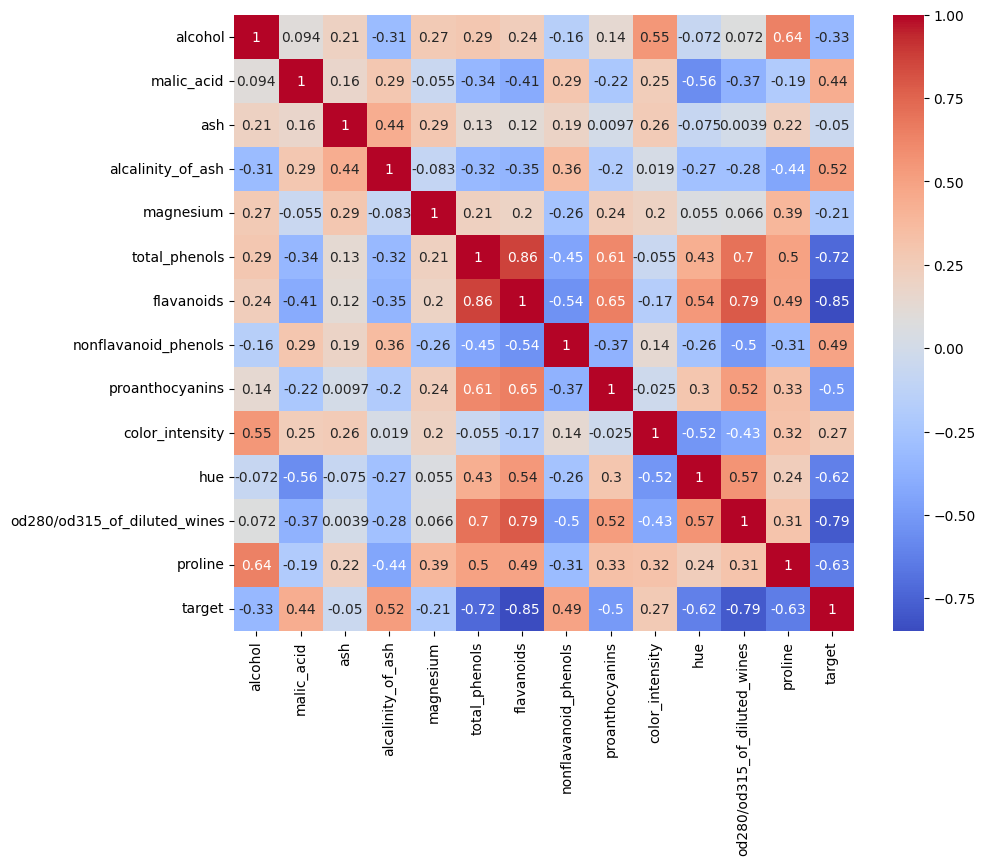

In [8]:
# Check for correlations in features
# indicates the degree to which two variables are linearly related
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot = True, cmap = 'coolwarm')

## DATA PREPROCESSING

In [9]:
# Split data into training and test set 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

# Scale X data because nns are scale sensitive
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) # you dont have to fit transform twice

In [10]:
# To view y train data: 3 classes
y_train

array([1, 0, 2, 0, 0, 2, 1, 0, 2, 2, 2, 2, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1,
       1, 0, 1, 2, 0, 0, 1, 2, 1, 2, 0, 1, 2, 1, 1, 1, 1, 0, 1, 0, 2, 1,
       2, 1, 0, 2, 1, 2, 1, 1, 1, 1, 1, 1, 0, 2, 0, 0, 2, 1, 0, 2, 1, 2,
       0, 1, 2, 1, 1, 2, 0, 0, 0, 1, 1, 0, 0, 0, 2, 1, 2, 1, 2, 1, 0, 0,
       0, 2, 1, 2, 0, 0, 1, 1, 1, 2, 0, 1, 1, 2, 2, 2, 1, 0, 1, 0, 1, 2,
       1, 1, 1, 2, 2, 2, 1, 0, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 2, 0,
       1, 2, 2, 1, 2, 0, 2, 2, 2, 2])

In [11]:
# Convert above data to tensors -> tensor dataset -> load w/ data loader
X_train_scaled_tensor = torch.tensor(X_train_scaled, dtype = torch.float)
X_test_scaled_tensor = torch.tensor(X_test_scaled, dtype = torch.float)

# note: never unsqueeze your target (y) when using nn.CrossEntropyLoss
y_train_tensor = torch.tensor(y_train, dtype = torch.long) # add extra dims for training since this is 1D data
y_test_tensor = torch.tensor(y_test, dtype = torch.long)

'''
NOTE: 
If your target is class labels (0, 1, 2, ..., 9, "cat", "dog", etc.) → use .long()
If your target is a real number (price, temperature, etc.) → use .float()
'''

'\nNOTE: \nIf your target is class labels (0, 1, 2, ..., 9, "cat", "dog", etc.) → use .long()\nIf your target is a real number (price, temperature, etc.) → use .float()\n'

In [12]:
# Create tensor dataset and data loader
train_dataset = TensorDataset(X_train_scaled_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size = 32, shuffle = True)

In [13]:
# to confirm 32 is a good batch size. Based on first val in array
X_train_scaled_tensor.shape

# this shows we have 13 features for each of the 142 instances. Hence first layer wud have 13 neurons

torch.Size([142, 13])

## MODEL ARCHITECTURE

In [14]:
# Define our neural network
class WineNet(nn.Module):

    def __init__ (self):
        super(WineNet, self).__init__()
        self.fc1 = nn.Linear(13, 64) # 13 i/p neurons for features
        self.fc2 = nn.Linear(64, 32) 
        self.fc3 = nn.Linear(32, 3)

        self.dropout = nn.Dropout(0.5) # for regularization

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x) # no activation needed: cos CrossEntropyLoss combines LogSoftmax + NLLLoss internally

        return x   # return raw logits     

Quick rule:

FINAL LAYER ACTIVATION FUNCTION

Binary classification → sigmoid.
Multi-class → softmax.
Regression → linear (no activation)

LOSS FUNCTION

Binary classification → Binary cross entropy.
Multi-class → Categorical cross entropy (if labels are one hot encoded), Sparse categorical cross entropy (if labels are integers)

In [15]:
# Create model 
model = WineNet()

In [16]:
# Define loss function (criterion) and optimizer
criterion = nn.CrossEntropyLoss() # handles softmax
optimizer = optim.Adam(model.parameters(), lr = 0.001)

In [17]:
# Define the training loop
epochs = 20

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    # iterate over data loader to get batches
    for x_batch, y_batch in train_loader:
        optimizer.zero_grad() # set grads to zero

        preds = model(x_batch)
        loss = criterion(preds, y_batch)

        loss.backward() # backpropagate loss
        optimizer.step() # take step w/ optim in right direction

        running_loss += loss.item()

    print(f'Epoch {epoch + 1}: Loss was: {running_loss/len(train_loader)}')

Epoch 1: Loss was: 1.0730414628982543
Epoch 2: Loss was: 1.0235064506530762
Epoch 3: Loss was: 0.978862714767456
Epoch 4: Loss was: 0.9036039113998413
Epoch 5: Loss was: 0.8506411194801331
Epoch 6: Loss was: 0.7856190085411072
Epoch 7: Loss was: 0.7435134768486023
Epoch 8: Loss was: 0.6495764970779419
Epoch 9: Loss was: 0.5949887156486511
Epoch 10: Loss was: 0.5390736818313598
Epoch 11: Loss was: 0.48187037110328673
Epoch 12: Loss was: 0.3973486363887787
Epoch 13: Loss was: 0.3527392208576202
Epoch 14: Loss was: 0.29631292521953584
Epoch 15: Loss was: 0.2883739948272705
Epoch 16: Loss was: 0.27697545289993286
Epoch 17: Loss was: 0.20664720833301545
Epoch 18: Loss was: 0.19909631609916686
Epoch 19: Loss was: 0.14966708421707153
Epoch 20: Loss was: 0.1605519622564316


## MODEL EVALUATION

In [18]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Evaluate model
model.eval()

with torch.no_grad():
    logits = model(X_test_scaled_tensor) # Raw unnormalized output scores
    probs = torch.softmax(logits, dim = 1) # Convert logits to probabilities (sum to 1 across classes)
    preds = torch.argmax(probs, dim = 1) # Pick the class with the highest probability

    correct = (preds == y_test_tensor).sum().item() # Count how many predictions match true labels
    accuracy = correct / len(y_test_tensor) * 100

    # FOR OTHER METRICS
    # Convert tensors to numpy for sklearn metrics
    y_true = y_test_tensor.numpy()
    y_pred = preds.numpy()

    precision = precision_score(y_true, y_pred, average='weighted') # weighted is used when Classes are imbalanced — weighs by class frequency
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')

print(f'Accuracy: {accuracy:.2f}%')
print(f"Precision: {precision:.2f}")
print(f"Recall:    {recall:.2f}")
print(f"F1 Score:  {f1:.2f}")

Accuracy: 97.22%
Precision: 0.98
Recall:    0.97
F1 Score:  0.97
